# Thesis Evaluation 2 — Architecture × Search Strategy Analysis

**Focus:**
1. **3×3 grid** — composite & per-metric scores across all architecture/search combinations (gpt-4o-mini, excl. unanswerable)
2. **Baseline architecture** — how search strategies (Semantic / BM25 / Hybrid) differ across every question type (including *unanswerable*)

Run cells top-to-bottom. MLflow must be running at `http://localhost:8567`.

In [23]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from mlflow.tracking import MlflowClient

# ── Style ─────────────────────────────────────────────────────────────────────
sns.set_theme(style="white", context="notebook", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

PALETTE = ["#0173B2", "#DE8F05", "#029E73", "#D55E00", "#CC78BC", "#CA9161"]
SEARCH_COLORS = {"Semantic": "#0173B2", "BM25": "#DE8F05", "Hybrid": "#029E73"}
QC_COLORS = {
    "fact_single":   "#0173B2",
    "summary":       "#DE8F05",
    "reasoning":     "#029E73",
    "unanswerable":  "#D55E00",
}
QC_DISPLAY = {
    "fact_single":  "Factual (single-hop)",
    "summary":      "Summary",
    "reasoning":    "Reasoning",
    "unanswerable": "Unanswerable",
}

SAVE_FIGS = True
FIGURES_DIR = Path("figures2")
FIGURES_DIR.mkdir(exist_ok=True)

def savefig(name: str):
    if SAVE_FIGS:
        for ext in ("pdf", "png"):
            plt.savefig(FIGURES_DIR / f"{name}.{ext}", bbox_inches="tight", dpi=300)
        print(f"  Saved: figures2/{name}.(pdf|png)")

In [24]:
MLFLOW_TRACKING_URI  = "http://localhost:8567"
RAGAS_TABLE_ARTIFACT = "ragas_scores.json"

METRIC_COLS = [
    "faithfulness",
    "context_precision",
    "context_recall",
    "answer_relevance",
    "factual_correctness",
    "factual_correctness_recall",
]
METRIC_SHORT = {
    "faithfulness":               "Faith.",
    "context_precision":          "Ctx.Prec.",
    "context_recall":             "Ctx.Rec.",
    "answer_relevance":           "Ans.Rel.",
    "factual_correctness":        "FC",
    "factual_correctness_recall": "FCRec.",
}
METRIC_LONG = {
    "faithfulness":               "Faithfulness",
    "context_precision":          "Context Precision",
    "context_recall":             "Context Recall",
    "answer_relevance":           "Answer Relevance",
    "factual_correctness":        "Factual Correctness",
    "factual_correctness_recall": "FC Recall",
}

EXCLUDE_CLASSES = ["unanswerable"]
QUESTION_CLASSES_ALL = ["fact_single", "summary", "reasoning", "unanswerable"]

# ── Run definitions ────────────────────────────────────────────────────────────
ARCHS    = ["Baseline", "Query Rewriting", "RAG Agent"]
SEARCHES = ["Semantic", "BM25", "Hybrid"]

GRID_IDS = {
    ("Baseline",        "Semantic"): "f6d783f661a644a58865384534021c32",
    ("Baseline",        "BM25"):     "144d504d4b1b454f8505f54697c69250",
    ("Baseline",        "Hybrid"):   "2ebab2b7d6ad46859eab992a06c5ccad",
    ("Query Rewriting", "Semantic"): "92647f9427f74a0ea710d0cf731ec0ea",
    ("Query Rewriting", "BM25"):     "e5483a9635b34c8895ecdfabc45674c4",
    ("Query Rewriting", "Hybrid"):   "412a730db5e04a4da436218d6321d1cd",
    ("RAG Agent",       "Semantic"): "7b33b7a6b88b420e93d6c56f8bca4416",
    ("RAG Agent",       "BM25"):     "9b9b5ef53cfd4bb1a8ad8324ce01e251",
    ("RAG Agent",       "Hybrid"):   "d0fd5a3181f947a9a993417e86c50e28",
}

BASELINE_RUNS = [
    ("f6d783f661a644a58865384534021c32", "Semantic"),
    ("144d504d4b1b454f8505f54697c69250", "BM25"),
    ("2ebab2b7d6ad46859eab992a06c5ccad", "Hybrid"),
]

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()
print(f"Tracking URI: {MLFLOW_TRACKING_URI}")

Tracking URI: http://localhost:8567


In [25]:
def _list_artifacts(run_id: str, path: str = "") -> list:
    items = []
    for art in client.list_artifacts(run_id, path):
        items.append(art.path)
        if art.is_dir:
            items.extend(_list_artifacts(run_id, art.path))
    return items


def load_run(run_id: str) -> pd.DataFrame:
    matches = [p for p in _list_artifacts(run_id) if p.endswith(RAGAS_TABLE_ARTIFACT)]
    if not matches:
        raise FileNotFoundError(f"No {RAGAS_TABLE_ARTIFACT} for {run_id}")
    local = client.download_artifacts(run_id, matches[0])
    with open(local) as f:
        payload = json.load(f)
    if isinstance(payload, list):
        df = pd.DataFrame(payload)
    elif "data" in payload:
        df = pd.DataFrame(payload["data"], columns=payload["columns"])
    else:
        df = pd.DataFrame(payload)
    for col in METRIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def mean_scores(df: pd.DataFrame, exclude=None) -> pd.Series:
    if exclude is None:
        exclude = EXCLUDE_CLASSES
    sub = df[~df["question_class"].isin(exclude)] if exclude else df
    return sub[METRIC_COLS].mean(numeric_only=True)


def _annotate_heatmap(ax, data: np.ndarray, fontsize: float = 9):
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            v = data[r, c]
            if not np.isnan(v):
                text_color = "black" if 0.30 < v < 0.82 else "white"
                ax.text(c, r, f"{v:.3f}", ha="center", va="center",
                        fontsize=fontsize, color=text_color)

print("Helpers loaded.")

Helpers loaded.


In [26]:
all_run_ids: set = set(GRID_IDS.values())

print(f"Loading {len(all_run_ids)} unique runs...")
all_data: dict[str, pd.DataFrame] = {}

for run_id in sorted(all_run_ids):
    try:
        all_data[run_id] = load_run(run_id)
        print(f"  OK   {run_id[:8]}  ({len(all_data[run_id])} rows)")
    except Exception as e:
        print(f"  FAIL {run_id[:8]}: {e}")

print(f"\nLoaded {len(all_data)}/{len(all_run_ids)} runs.")

# Quick sanity check on question class distribution
sample = all_data[GRID_IDS[("Baseline", "Semantic")]]
print("\nQuestion class distribution:")
print(sample["question_class"].value_counts().to_string())

Loading 9 unique runs...


  OK   144d504d  (20 rows)


  OK   2ebab2b7  (20 rows)


  OK   412a730d  (20 rows)


  OK   7b33b7a6  (20 rows)


  OK   92647f94  (20 rows)


  OK   9b9b5ef5  (20 rows)


  OK   d0fd5a31  (20 rows)


  OK   e5483a96  (20 rows)


  OK   f6d783f6  (20 rows)

Loaded 9/9 runs.

Question class distribution:
question_class
fact_single     5
summary         5
reasoning       5
unanswerable    5


---
## 1 — 3×3 Grid: Architecture × Search Strategy

All 9 combinations with **gpt-4o-mini** as judge/LLM.  
Scores exclude *unanswerable* questions (consistent with aggregate evaluation).

**Left panel** — composite score (mean of all 6 RAGAS metrics) shown as a 3×3 heatmap, one cell per configuration.  
**Right panel** — full per-metric breakdown, all 9 configurations × 6 metrics.

  Saved: figures2/grid_3x3.(pdf|png)


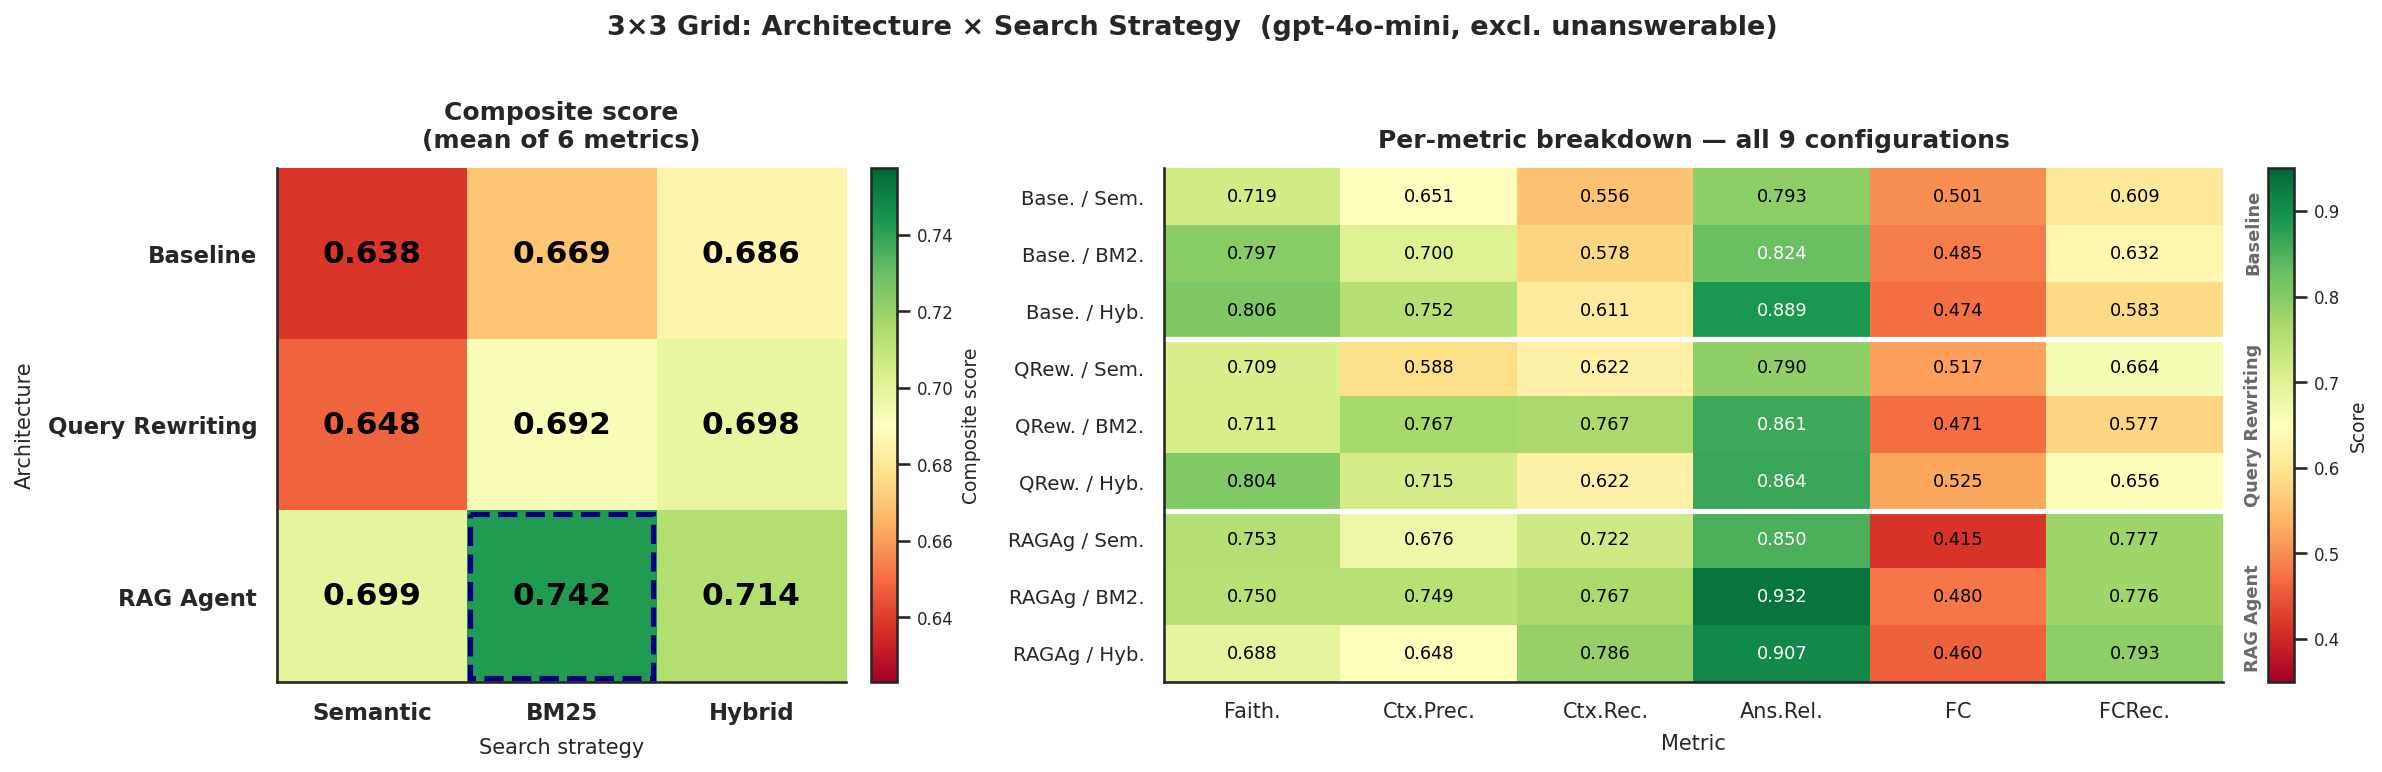


Composite score table (rows=arch, cols=search):


,Semantic,BM25,Hybrid
Baseline,0.6381,0.6693,0.6858
Query Rewriting,0.6482,0.6923,0.6977
RAG Agent,0.6988,0.7425,0.7136


In [27]:
# ── Compute composite and per-metric scores for all 9 cells ──────────────────
grid_composite: dict = {}
grid_per_metric: dict = {}

for (arch, search), rid in GRID_IDS.items():
    ms = mean_scores(all_data[rid])            # excludes unanswerable
    grid_composite[(arch, search)] = ms.mean()
    grid_per_metric[(arch, search)] = ms

comp_matrix = np.array([
    [grid_composite[(arch, s)] for s in SEARCHES]
    for arch in ARCHS
])

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5),
                         gridspec_kw={"width_ratios": [1, 1.8]})

# ── Left: 3×3 composite heatmap ───────────────────────────────────────────────
ax = axes[0]
vlo = comp_matrix.min() - 0.015
vhi = comp_matrix.max() + 0.015
im = ax.imshow(comp_matrix, cmap="RdYlGn", vmin=vlo, vmax=vhi, aspect="auto")
cbar = plt.colorbar(im, ax=ax, fraction=0.055, pad=0.04)
cbar.set_label("Composite score", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_xticks(range(len(SEARCHES)))
ax.set_xticklabels(SEARCHES, fontsize=11, fontweight="bold")
ax.set_yticks(range(len(ARCHS)))
ax.set_yticklabels(ARCHS, fontsize=11, fontweight="bold")
ax.set_xlabel("Search strategy", labelpad=6)
ax.set_ylabel("Architecture", labelpad=6)
ax.set_title("Composite score\n(mean of 6 metrics)", pad=10)

for r, arch in enumerate(ARCHS):
    for c, s in enumerate(SEARCHES):
        v = comp_matrix[r, c]
        fc = "black" if 0.48 < v < 0.80 else "white"
        ax.text(c, r, f"{v:.3f}", ha="center", va="center",
                fontsize=15, fontweight="bold", color=fc)

# Best cell marker
best_r, best_c = np.unravel_index(comp_matrix.argmax(), comp_matrix.shape)
ax.add_patch(plt.Rectangle(
    (best_c - 0.48, best_r - 0.48), 0.96, 0.96,
    fill=False, edgecolor="navy", linewidth=2.5, linestyle="--", zorder=5
))

# ── Right: per-metric breakdown (9 × 6) ───────────────────────────────────────
ax2 = axes[1]
row_labels = [f"{arch[:5]}/{s[:3]}" for arch in ARCHS for s in SEARCHES]
ARCH_SHORT = {"Baseline": "Base.", "Query Rewriting": "QRew.", "RAG Agent": "RAGAg"}
row_labels_clean = [
    f"{ARCH_SHORT[arch]} / {s[:3]}."
    for arch in ARCHS for s in SEARCHES
]
full_matrix = np.array([
    [grid_per_metric[(arch, s)][m] for m in METRIC_COLS]
    for arch in ARCHS for s in SEARCHES
])

im2 = ax2.imshow(full_matrix, cmap="RdYlGn", vmin=0.35, vmax=0.95, aspect="auto")
cbar2 = plt.colorbar(im2, ax=ax2, fraction=0.025, pad=0.04)
cbar2.set_label("Score", fontsize=9)
cbar2.ax.tick_params(labelsize=8)

ax2.set_xticks(range(len(METRIC_COLS)))
ax2.set_xticklabels([METRIC_SHORT[m] for m in METRIC_COLS], fontsize=10)
ax2.set_yticks(range(9))
ax2.set_yticklabels(row_labels_clean, fontsize=9.5)
ax2.set_xlabel("Metric", labelpad=6)
ax2.set_title("Per-metric breakdown — all 9 configurations", pad=10)

_annotate_heatmap(ax2, full_matrix, fontsize=8.5)

# Separator lines between architecture groups
for sep in [3, 6]:
    ax2.axhline(sep - 0.5, color="white", linewidth=2.5)

# Architecture bracket labels on the right
for i, arch in enumerate(ARCHS):
    mid_y = i * 3 + 1
    ax2.annotate(
        arch,
        xy=(1.02, (8 - mid_y) / 8),   # axes fraction: y is inverted
        xycoords="axes fraction",
        fontsize=8.5,
        fontweight="bold",
        va="center",
        rotation=90,
        color="dimgray",
    )

plt.suptitle(
    "3×3 Grid: Architecture × Search Strategy  (gpt-4o-mini, excl. unanswerable)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
savefig("grid_3x3")
plt.show()

# ── Summary table ──────────────────────────────────────────────────────────────
print("\nComposite score table (rows=arch, cols=search):")
comp_df = pd.DataFrame(comp_matrix, index=ARCHS, columns=SEARCHES)
display(comp_df.style
    .format("{:.4f}")
    .background_gradient(axis=None, cmap="RdYlGn", vmin=vlo, vmax=vhi)
    .set_caption("Composite score = mean of 6 RAGAS metrics, excl. unanswerable")
)

---
## 2 — Baseline Architecture: Search Strategy × Question Type

**Fixed:** Baseline architecture, gpt-4o-mini.  
**Varied:** Semantic / BM25 / Hybrid retrieval.  
**Split by:** All four question classes — *factual, summary, reasoning, unanswerable*.

Three views:
- **Grouped bars** — absolute scores per class
- **Delta vs Semantic** — where BM25 and Hybrid gain or lose
- **Heatmap summary** — compact overview for all combinations

In [28]:
# ── Build per-question-class tables for each search strategy ─────────────────
qc_tables: dict[str, pd.DataFrame] = {}   # {qc: DataFrame(rows=searches, cols=metrics)}

for qc in QUESTION_CLASSES_ALL:
    rows = {}
    for rid, label in BASELINE_RUNS:
        subset = all_data[rid][all_data[rid]["question_class"] == qc]
        if len(subset) > 0:
            rows[label] = subset[METRIC_COLS].mean(numeric_only=True)
        else:
            rows[label] = pd.Series({m: np.nan for m in METRIC_COLS})
    qc_tables[qc] = pd.DataFrame(rows).T

# Print counts (from Semantic run — same across all baseline runs)
ref_df = all_data[BASELINE_RUNS[0][0]]
print("Question class counts (same across all baseline runs):")
for qc in QUESTION_CLASSES_ALL:
    n = (ref_df["question_class"] == qc).sum()
    print(f"  {QC_DISPLAY[qc]:<28}  n={n}")

print("\nPer class × per search mean scores:")
for qc in QUESTION_CLASSES_ALL:
    print(f"\n  [{QC_DISPLAY[qc]}]")
    display(qc_tables[qc].style
        .format("{:.4f}")
        .background_gradient(axis=None, cmap="RdYlGn", vmin=0.0, vmax=1.0)
        .set_caption(QC_DISPLAY[qc])
    )

Question class counts (same across all baseline runs):
  Factual (single-hop)          n=5
  Summary                       n=5
  Reasoning                     n=5
  Unanswerable                  n=5

Per class × per search mean scores:

  [Factual (single-hop)]


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
Semantic,0.8700,0.7706,0.8000,0.8964,0.7180,0.9000
BM25,0.8000,0.6306,0.8000,0.7226,0.6720,0.9000
Hybrid,0.8000,0.7971,0.8000,0.7760,0.4740,0.6000



  [Summary]


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
Semantic,0.4930,0.5278,0.3667,0.5504,0.2500,0.3140
BM25,0.8947,0.7761,0.4333,0.8404,0.4300,0.5040
Hybrid,0.8049,0.6968,0.4333,0.9362,0.4060,0.5120



  [Reasoning]


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
Semantic,0.7925,0.6561,0.5000,0.9318,0.5340,0.6140
BM25,0.6971,0.6933,0.5000,0.9079,0.3540,0.4920
Hybrid,0.8143,0.7625,0.6000,0.9545,0.5420,0.6360



  [Unanswerable]


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
Semantic,0.6571,0.0000,0.0000,0.0000,0.8800,1.0000
BM25,0.6000,0.0667,0.2000,0.1821,0.8000,0.8000
Hybrid,0.8000,0.0000,0.0000,0.0000,0.9720,1.0000


  Saved: figures2/baseline_search_by_qclass.(pdf|png)


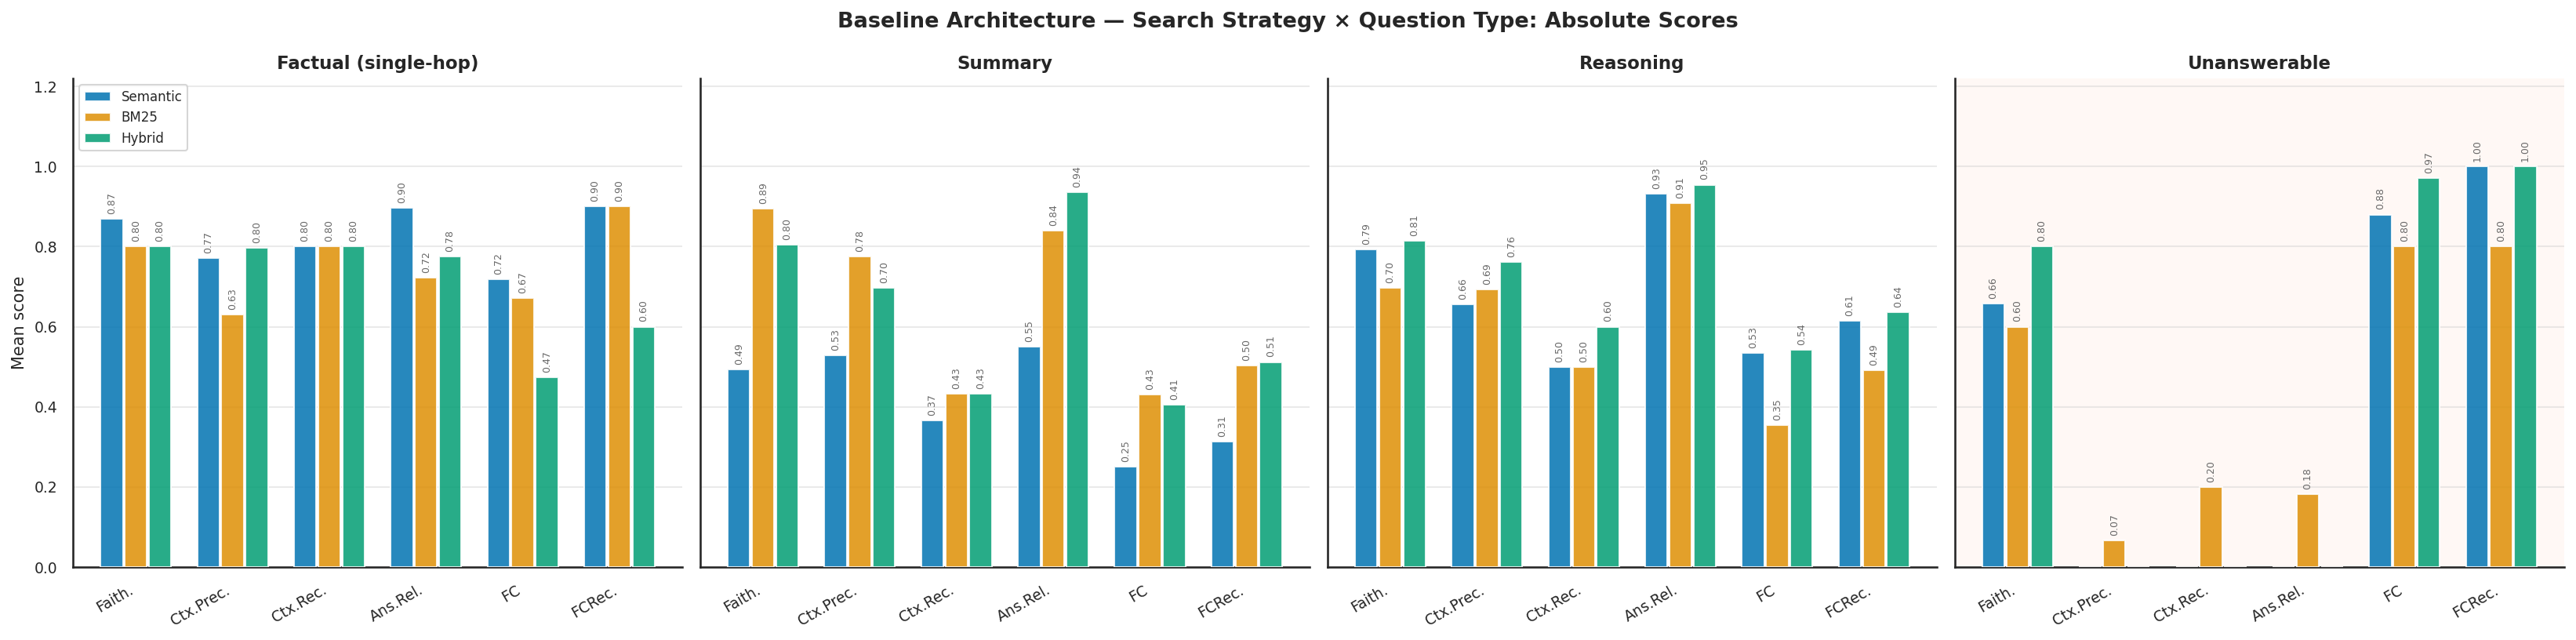

In [29]:
# ── Fig 2a: Grouped bar chart — one panel per question class ────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharey=True)

for ax, qc in zip(axes, QUESTION_CLASSES_ALL):
    table = qc_tables[qc]
    metrics = METRIC_COLS
    x = np.arange(len(metrics))
    n = len(BASELINE_RUNS)
    w = 0.75 / n

    for i, (_, label) in enumerate(BASELINE_RUNS):
        scores = table.loc[label, metrics].values.astype(float)
        offset = (i - (n - 1) / 2) * w
        color = SEARCH_COLORS[label]
        bars = ax.bar(x + offset, scores, w * 0.92,
                      label=label, color=color, alpha=0.85, zorder=3)
        for bar, v in zip(bars, scores):
            if not np.isnan(v) and v > 0.02:
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.012,
                        f"{v:.2f}", ha="center", va="bottom",
                        fontsize=6, rotation=90, color="dimgray")

    ax.set_xticks(x)
    ax.set_xticklabels([METRIC_SHORT[m] for m in metrics], rotation=30, ha="right")
    ax.set_ylim(0, 1.22)
    ax.set_title(QC_DISPLAY[qc], fontsize=11)
    ax.grid(axis="y", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    if ax is axes[0]:
        ax.set_ylabel("Mean score")
        ax.legend(loc="upper left", fontsize=8)

# Shade unanswerable panel to visually distinguish it
axes[-1].set_facecolor("#fff8f5")

plt.suptitle(
    "Baseline Architecture — Search Strategy × Question Type: Absolute Scores",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
savefig("baseline_search_by_qclass")
plt.show()

  Saved: figures2/baseline_search_delta_by_qclass.(pdf|png)


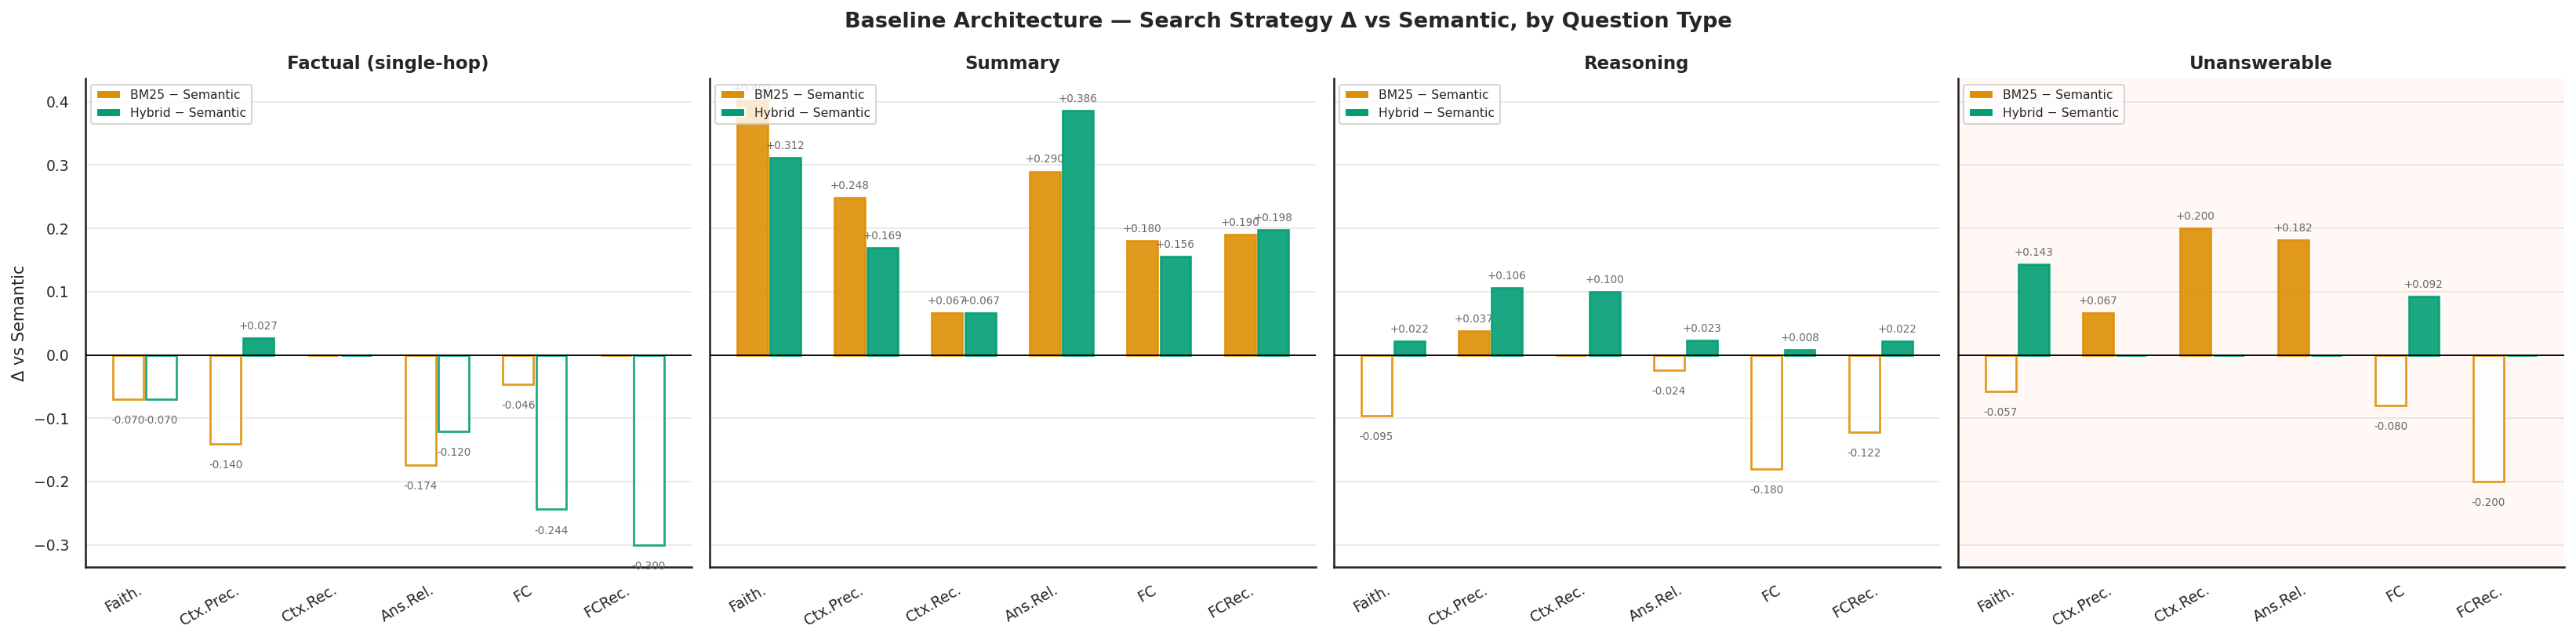

In [30]:
# ── Fig 2b: Delta chart — BM25 and Hybrid vs Semantic ───────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 5.5), sharey=True)

DELTA_LABELS = ["BM25", "Hybrid"]

for ax, qc in zip(axes, QUESTION_CLASSES_ALL):
    table = qc_tables[qc]
    base = table.loc["Semantic", METRIC_COLS]
    x = np.arange(len(METRIC_COLS))
    w = 0.34

    for i, label in enumerate(DELTA_LABELS):
        delta = (table.loc[label, METRIC_COLS] - base).values.astype(float)
        offset = (i - (len(DELTA_LABELS) - 1) / 2) * w
        color = SEARCH_COLORS[label]

        for xi, v in zip(x + offset, delta):
            if np.isnan(v):
                continue
            face = color if v >= 0 else "white"
            ax.bar(xi, v, w * 0.92,
                   color=face, edgecolor=color, linewidth=1.3,
                   alpha=0.9, zorder=3)
            if abs(v) > 0.004:
                ypos = v + (0.010 if v >= 0 else -0.025)
                va   = "bottom" if v >= 0 else "top"
                ax.text(xi, ypos, f"{v:+.3f}",
                        ha="center", va=va, fontsize=6.5, color="dimgray")

    ax.axhline(0, color="black", linewidth=0.9, zorder=5)
    ax.set_xticks(x)
    ax.set_xticklabels([METRIC_SHORT[m] for m in METRIC_COLS], rotation=30, ha="right")
    ax.set_title(QC_DISPLAY[qc], fontsize=11)
    ax.grid(axis="y", alpha=0.4, zorder=0)
    ax.set_axisbelow(True)
    if ax is axes[0]:
        ax.set_ylabel("Δ vs Semantic")

    handles = [
        mpatches.Patch(facecolor=SEARCH_COLORS[lbl], label=f"{lbl} − Semantic")
        for lbl in DELTA_LABELS
    ]
    ax.legend(handles=handles, loc="upper left", fontsize=7.5)

axes[-1].set_facecolor("#fff8f5")

plt.suptitle(
    "Baseline Architecture — Search Strategy Δ vs Semantic, by Question Type",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
savefig("baseline_search_delta_by_qclass")
plt.show()

  Saved: figures2/baseline_search_heatmap_by_qclass.(pdf|png)


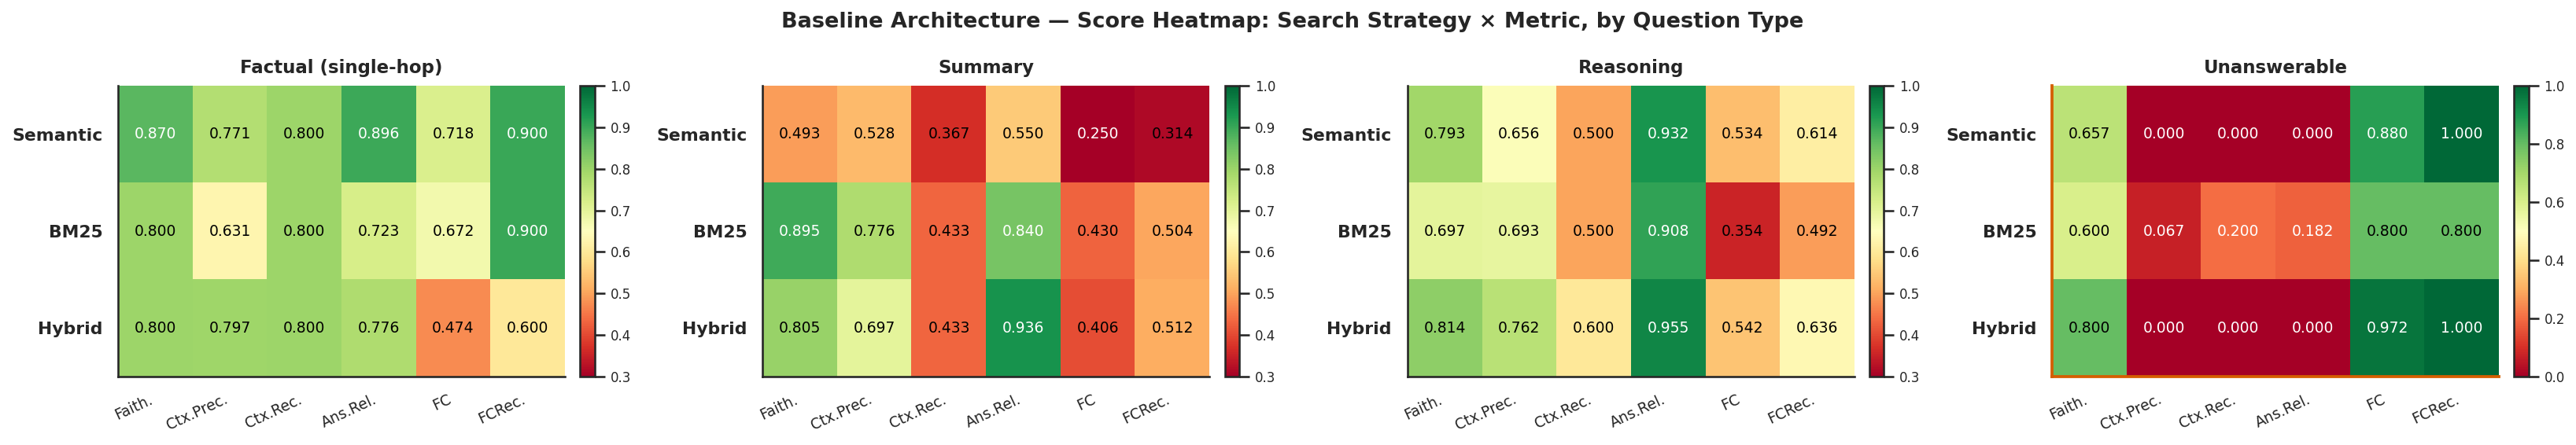

In [31]:
# ── Fig 2c: Heatmap summary — search strategies × metrics, per question class ─
fig, axes = plt.subplots(1, 4, figsize=(22, 3.8))

for ax, qc in zip(axes, QUESTION_CLASSES_ALL):
    table = qc_tables[qc]
    data = table[METRIC_COLS].astype(float).values

    # Unanswerable scores are typically near 0 or NaN — use a 0–1 scale
    vmin = 0.0 if qc == "unanswerable" else 0.30
    vmax = 1.0

    im = ax.imshow(data, cmap="RdYlGn", vmin=vmin, vmax=vmax, aspect="auto")
    cbar = plt.colorbar(im, ax=ax, fraction=0.08, pad=0.03)
    cbar.ax.tick_params(labelsize=8)

    ax.set_xticks(range(len(METRIC_COLS)))
    ax.set_xticklabels([METRIC_SHORT[m] for m in METRIC_COLS],
                       fontsize=9, rotation=25, ha="right")
    ax.set_yticks(range(3))
    ax.set_yticklabels(list(table.index), fontsize=10.5, fontweight="bold")
    ax.set_title(QC_DISPLAY[qc], fontsize=11, pad=8)

    _annotate_heatmap(ax, data, fontsize=9)

    if qc == "unanswerable":
        for spine in ax.spines.values():
            spine.set_edgecolor("#D55E00")
            spine.set_linewidth(1.8)

plt.suptitle(
    "Baseline Architecture — Score Heatmap: Search Strategy × Metric, by Question Type",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
savefig("baseline_search_heatmap_by_qclass")
plt.show()

---
## 3 — Axis 3: LLM Model Comparison

**Fixed:** RAG Agent architecture, Hybrid search strategy.  
**Varied:** Gemma4:e4b (local) / Qwen3.5:9b (local) / GPT-4o-mini / GPT-5.4.

Three views:
- **Main heatmap** — all models × all metrics, with composite score annotated per row
- **Radar chart** — all 6 metrics per model on a single spider plot
- **Per-question-type heatmaps** — 4 panels including *unanswerable*, dashed separator between local and commercial models

In [32]:
# ── Axis 3 run definitions ─────────────────────────────────────────────────────
AXIS3_RUNS = [
    ("7e34b19e653d4df09f9dc59d9a488d86", "Gemma4:e4b (local)"),
    ("801c6a24a60b4f689a38fcdb1de87e49", "Qwen3.5:9b (local)"),
    ("d0fd5a3181f947a9a993417e86c50e28", "GPT-4o-mini"),
    ("7021198023d34038929cdeebe7cbea4c", "GPT-5.4"),
]

# Load any runs not already in all_data
for rid, label in AXIS3_RUNS:
    if rid not in all_data:
        try:
            all_data[rid] = load_run(rid)
            print(f"  Loaded {rid[:8]}  ({len(all_data[rid])} rows)  → {label}")
        except Exception as e:
            print(f"  FAIL  {rid[:8]}: {e}")
    else:
        print(f"  Already loaded {rid[:8]}  → {label}")

# Aggregate table (excl. unanswerable — consistent with other axes)
axis3_table = pd.DataFrame(
    {label: mean_scores(all_data[rid]) for rid, label in AXIS3_RUNS}
).T

display(axis3_table.style
    .format("{:.4f}")
    .background_gradient(axis=None, cmap="RdYlGn", vmin=0.35, vmax=0.95)
    .set_caption("Axis 3 — LLM Model  (RAG Agent / Hybrid, excl. unanswerable)")
)

  Loaded 7e34b19e  (20 rows)  → Gemma4:e4b (local)


  Loaded 801c6a24  (20 rows)  → Qwen3.5:9b (local)
  Already loaded d0fd5a31  → GPT-4o-mini


  Loaded 70211980  (20 rows)  → GPT-5.4


,faithfulness,context_precision,context_recall,answer_relevance,factual_correctness,factual_correctness_recall
Gemma4:e4b (local),0.6497,0.7842,0.6889,0.8304,0.3677,0.7669
Qwen3.5:9b (local),0.7584,0.7153,0.7778,0.9169,0.4407,0.8143
GPT-4o-mini,0.6883,0.6479,0.7857,0.9067,0.4600,0.7929
GPT-5.4,0.8234,0.8211,0.8222,0.8171,0.5082,0.9083


  Saved: figures2/axis3_main_heatmap.(pdf|png)


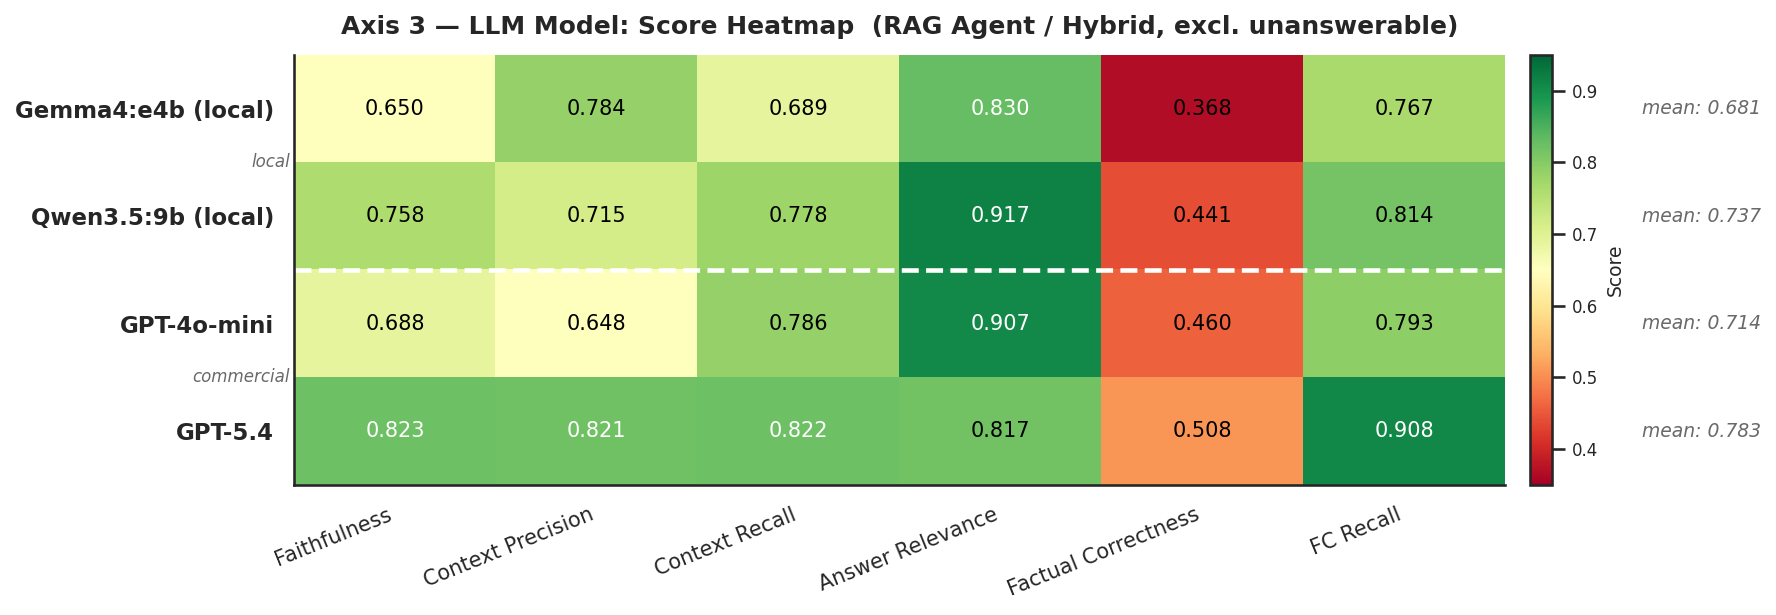

In [33]:
# ── Fig 3a: Main heatmap — all models × all metrics ─────────────────────────
labels   = list(axis3_table.index)
data_3a  = axis3_table[METRIC_COLS].astype(float).values
composite = data_3a.mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 4.2))

im = ax.imshow(data_3a, cmap="RdYlGn", vmin=0.35, vmax=0.95, aspect="auto")
cbar = plt.colorbar(im, ax=ax, fraction=0.022, pad=0.02)
cbar.set_label("Score", fontsize=9)
cbar.ax.tick_params(labelsize=8)

ax.set_xticks(range(len(METRIC_COLS)))
ax.set_xticklabels([METRIC_LONG[m] for m in METRIC_COLS],
                   fontsize=10, rotation=22, ha="right")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=11, fontweight="bold")
ax.set_title(
    "Axis 3 — LLM Model: Score Heatmap  (RAG Agent / Hybrid, excl. unanswerable)",
    pad=10
)

_annotate_heatmap(ax, data_3a, fontsize=10)

# Composite score annotation on the right of each row
for r, comp in enumerate(composite):
    ax.text(len(METRIC_COLS) + 0.18, r, f"mean: {comp:.3f}",
            ha="left", va="center", fontsize=9, color="dimgray", style="italic")

# Dashed separator between local (rows 0–1) and commercial (rows 2–3)
ax.axhline(1.5, color="white", linewidth=2.2, linestyle="--")
ax.text(-0.52, 0.5, "local", ha="right", va="center",
        fontsize=8, color="dimgray", style="italic")
ax.text(-0.52, 2.5, "commercial", ha="right", va="center",
        fontsize=8, color="dimgray", style="italic")

plt.tight_layout()
savefig("axis3_main_heatmap")
plt.show()

  Saved: figures2/axis3_radar.(pdf|png)


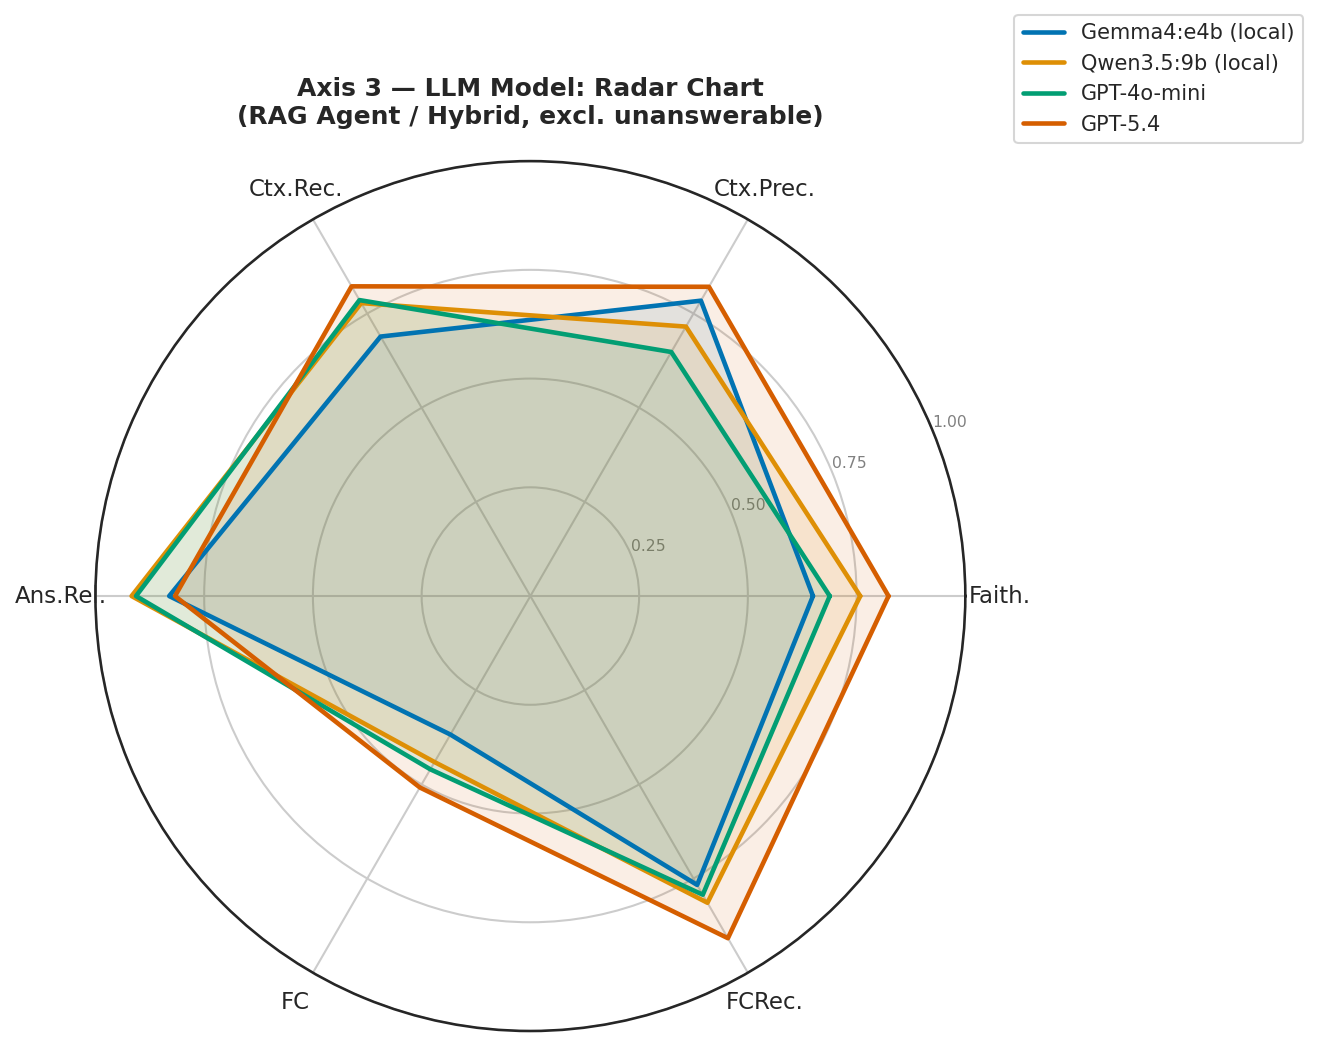

In [34]:
# ── Fig 3b: Radar chart — all models, all 6 metrics ─────────────────────────
N      = len(METRIC_COLS)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]   # close the polygon

fig = plt.figure(figsize=(8, 7))
ax_p = fig.add_subplot(111, projection="polar")

for i, (_, label) in enumerate(AXIS3_RUNS):
    vals = axis3_table.loc[label, METRIC_COLS].values.astype(float).tolist()
    vals += vals[:1]
    color = PALETTE[i]
    ax_p.plot(angles, vals, color=color, linewidth=2.2, label=label)
    ax_p.fill(angles, vals, color=color, alpha=0.10)

ax_p.set_xticks(angles[:-1])
ax_p.set_xticklabels([METRIC_SHORT[m] for m in METRIC_COLS], fontsize=11)
ax_p.set_ylim(0, 1)
ax_p.set_yticks([0.25, 0.50, 0.75, 1.00])
ax_p.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7.5, color="gray")
ax_p.set_title(
    "Axis 3 — LLM Model: Radar Chart\n(RAG Agent / Hybrid, excl. unanswerable)",
    pad=18, fontsize=12, fontweight="bold"
)
ax_p.legend(loc="upper right", bbox_to_anchor=(1.40, 1.18), fontsize=10)

plt.tight_layout()
savefig("axis3_radar")
plt.show()

  Saved: figures2/axis3_heatmap_by_qclass.(pdf|png)


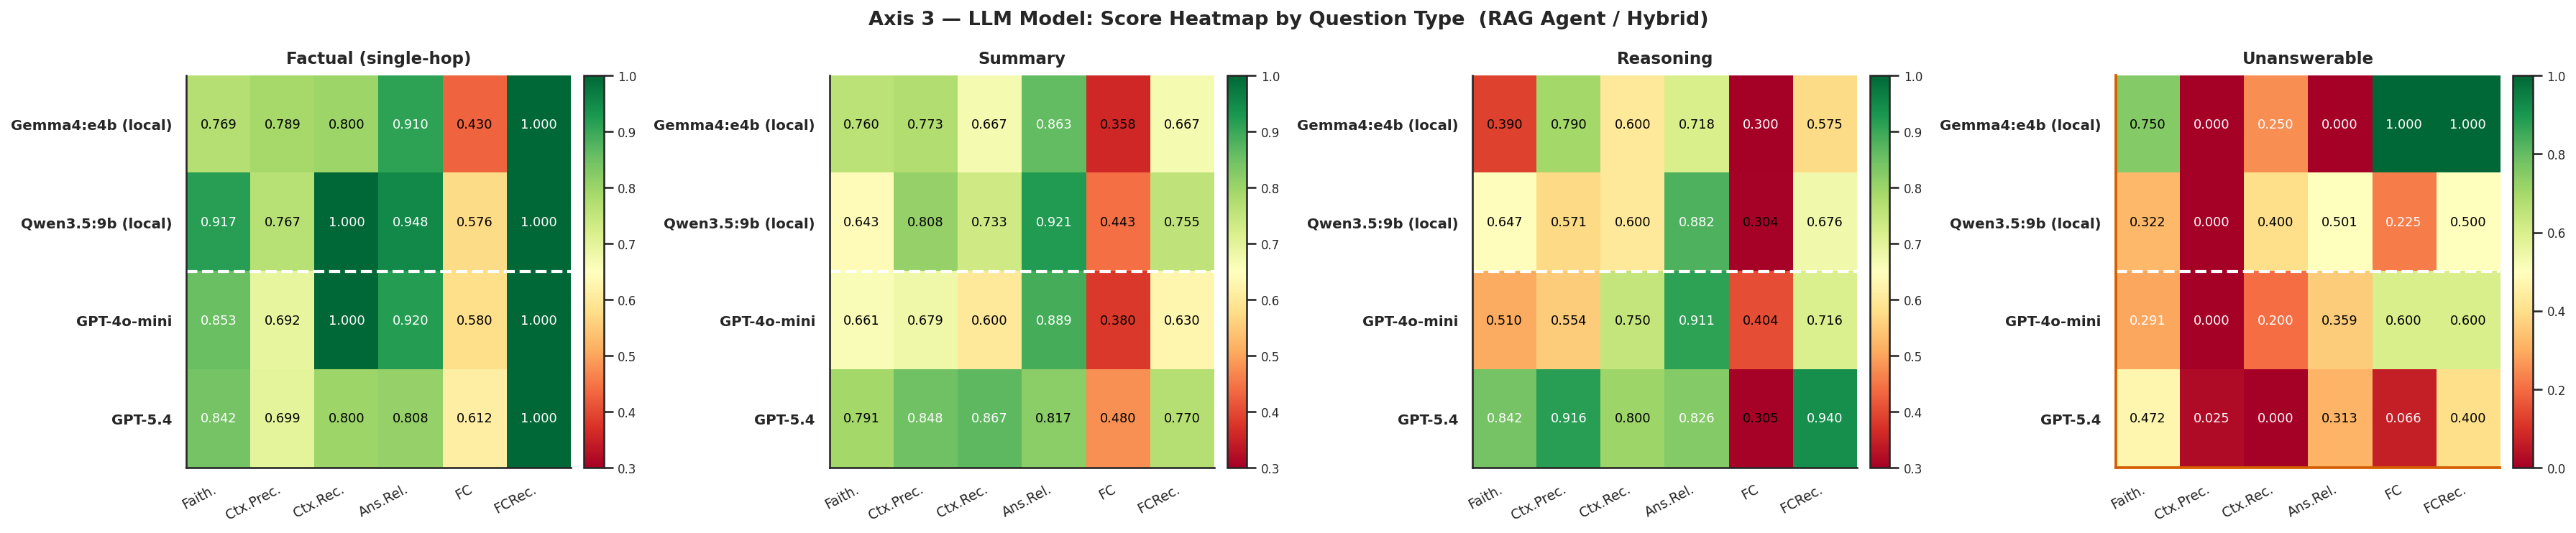

In [35]:
# ── Fig 3c: Per-question-type heatmaps — all 4 classes incl. unanswerable ────
fig, axes = plt.subplots(1, 4, figsize=(24, 5))

for ax, qc in zip(axes, QUESTION_CLASSES_ALL):
    rows = {}
    for rid, label in AXIS3_RUNS:
        subset = all_data[rid][all_data[rid]["question_class"] == qc]
        rows[label] = (
            subset[METRIC_COLS].mean(numeric_only=True)
            if len(subset) > 0
            else pd.Series({m: np.nan for m in METRIC_COLS})
        )
    qc_df   = pd.DataFrame(rows).T
    data_qc = qc_df[METRIC_COLS].astype(float).values

    # Unanswerable scores can be near 0 — open up the scale
    vmin = 0.0 if qc == "unanswerable" else 0.30
    vmax = 1.0

    im = ax.imshow(data_qc, cmap="RdYlGn", vmin=vmin, vmax=vmax, aspect="auto")
    cbar = plt.colorbar(im, ax=ax, fraction=0.08, pad=0.03)
    cbar.ax.tick_params(labelsize=8)

    ax.set_xticks(range(len(METRIC_COLS)))
    ax.set_xticklabels([METRIC_SHORT[m] for m in METRIC_COLS],
                       fontsize=9, rotation=28, ha="right")
    ax.set_yticks(range(len(AXIS3_RUNS)))
    ax.set_yticklabels(list(qc_df.index), fontsize=9.5, fontweight="bold")
    ax.set_title(QC_DISPLAY[qc], fontsize=11, pad=8)

    _annotate_heatmap(ax, data_qc, fontsize=8.5)

    # Dashed line between local (rows 0–1) and commercial (rows 2–3)
    ax.axhline(1.5, color="white", linewidth=2.0, linestyle="--")

    # Orange border on unanswerable panel
    if qc == "unanswerable":
        for spine in ax.spines.values():
            spine.set_edgecolor("#D55E00")
            spine.set_linewidth(1.8)

plt.suptitle(
    "Axis 3 — LLM Model: Score Heatmap by Question Type  (RAG Agent / Hybrid)",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
savefig("axis3_heatmap_by_qclass")
plt.show()